In [1]:
# Cell 1 - Install libraries (run only if missing)
!pip install -q pandas numpy scikit-learn xgboost imbalanced-learn shap gradio joblib matplotlib seaborn
print("Install step finished (skip if already installed).")

Install step finished (skip if already installed).


In [2]:
# Cell 2 - Imports
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, RandomOverSampler

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

import shap
import matplotlib.pyplot as plt

print("Libraries loaded.")

Libraries loaded.


In [3]:
# 📘 Cell 3 - Load dataset and rename columns to full forms

url = "https://raw.githubusercontent.com/dphi-official/Datasets/master/Chronic%20Kidney%20Disease%20%28CKD%29%20Dataset/ChronicKidneyDisease.csv"

# Load the dataset
df = pd.read_csv(url)
print("✅ Dataset loaded successfully.")
print("Shape:", df.shape)

# --- Rename abbreviated column names to full medical terms ---
rename_dict = {
    'age': 'Age',
    'bp': 'Blood_Pressure',
    'sg': 'Specific_Gravity',
    'al': 'Albumin',
    'su': 'Sugar',
    'rbc': 'Red_Blood_Cells',
    'pc': 'Pus_Cells',
    'pcc': 'Pus_Cell_Clumps',
    'ba': 'Bacteria',
    'bgr': 'Blood_Glucose_Random',
    'bu': 'Blood_Urea',
    'sc': 'Serum_Creatinine',
    'sod': 'Sodium',
    'pot': 'Potassium',
    'hemo': 'Hemoglobin',
    'pcv': 'Packed_Cell_Volume',
    'wc': 'White_Blood_Cell_Count',
    'rc': 'Red_Blood_Cell_Count',
    'htn': 'Hypertension',
    'dm': 'Diabetes_Mellitus',
    'cad': 'Coronary_Artery_Disease',
    'appet': 'Appetite',
    'pe': 'Pedal_Edema',
    'ane': 'Anemia'
}

# Apply renaming (ignore if some columns are not present)
df.rename(columns=rename_dict, inplace=True)

print("✅ Columns renamed to full medical names.")
print("\nColumns after renaming:\n", list(df.columns))

# Display first few rows for verification
display(df.head(4))


✅ Dataset loaded successfully.
Shape: (400, 26)
✅ Columns renamed to full medical names.

Columns after renaming:
 ['id', 'Age', 'Blood_Pressure', 'Specific_Gravity', 'Albumin', 'Sugar', 'Red_Blood_Cells', 'Pus_Cells', 'Pus_Cell_Clumps', 'Bacteria', 'Blood_Glucose_Random', 'Blood_Urea', 'Serum_Creatinine', 'Sodium', 'Potassium', 'Hemoglobin', 'Packed_Cell_Volume', 'White_Blood_Cell_Count', 'Red_Blood_Cell_Count', 'Hypertension', 'Diabetes_Mellitus', 'Coronary_Artery_Disease', 'Appetite', 'Pedal_Edema', 'Anemia', 'classification']


,id,Age,Blood_Pressure,Specific_Gravity,Albumin,Sugar,Red_Blood_Cells,Pus_Cells,Pus_Cell_Clumps,Bacteria,...,Packed_Cell_Volume,White_Blood_Cell_Count,Red_Blood_Cell_Count,Hypertension,Diabetes_Mellitus,Coronary_Artery_Disease,Appetite,Pedal_Edema,Anemia,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd


In [4]:
# Cell 4 - Basic cleaning & target detection
# Replace stray markers and strip whitespace
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)
df.replace(r'^\t*\?$', np.nan, regex=True, inplace=True)
df.replace(r'^\s*\?$', np.nan, regex=True, inplace=True)
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# Identify target column (common names)
if 'classification' in df.columns:
    target_col = 'classification'
elif 'class' in df.columns:
    target_col = 'class'
else:
    # fallback: assume last column is target
    target_col = df.columns[-1]
print("Using target column:", target_col)

# drop any accidental unnamed index columns if present
drop_cols = [c for c in df.columns if str(c).startswith('unnamed')]
if drop_cols:
    df.drop(columns=drop_cols, inplace=True)
    print("Dropped columns:", drop_cols)

display(df.head(3))
print("\nMissing value counts (top):")
display(df.isna().sum().sort_values(ascending=False).head(20))

Using target column: classification


,id,Age,Blood_Pressure,Specific_Gravity,Albumin,Sugar,Red_Blood_Cells,Pus_Cells,Pus_Cell_Clumps,Bacteria,...,Packed_Cell_Volume,White_Blood_Cell_Count,Red_Blood_Cell_Count,Hypertension,Diabetes_Mellitus,Coronary_Artery_Disease,Appetite,Pedal_Edema,Anemia,classification
0,0,48.0,80.0,1.02,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.02,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.01,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd



Missing value counts (top):


,0
Red_Blood_Cells,152
Red_Blood_Cell_Count,131
White_Blood_Cell_Count,106
Potassium,88
Sodium,87
Packed_Cell_Volume,71
Pus_Cells,65
Hemoglobin,52
Sugar,49
Specific_Gravity,47


In [5]:
# ✅ Cell 5 - Define categorical and numeric features properly after renaming

# Expected categorical features (based on renamed column names)
expected_cat = [
    'Red_Blood_Cells', 'Pus_Cells', 'Pus_Cell_Clumps', 'Bacteria',
    'Hypertension', 'Diabetes_Mellitus', 'Coronary_Artery_Disease',
    'Appetite', 'Pedal_Edema', 'Anemia'
]

# Keep only existing columns
cat_cols = [c for c in expected_cat if c in df.columns]

# Exclude ID (if any) and target column
exclude = set(cat_cols + [target_col, 'id', 'ID'])
num_cols = [c for c in df.columns if c not in exclude]

# ✅ Verify none are missing
missing_cats = [c for c in expected_cat if c not in df.columns]
if missing_cats:
    print("⚠️ Warning: These expected categorical columns are missing from dataset:", missing_cats)

print("✅ Categorical columns:", cat_cols)
print("✅ Numeric columns:", num_cols)
print(f"Total numeric: {len(num_cols)}, total categorical: {len(cat_cols)}")

✅ Categorical columns: ['Red_Blood_Cells', 'Pus_Cells', 'Pus_Cell_Clumps', 'Bacteria', 'Hypertension', 'Diabetes_Mellitus', 'Coronary_Artery_Disease', 'Appetite', 'Pedal_Edema', 'Anemia']
✅ Numeric columns: ['Age', 'Blood_Pressure', 'Specific_Gravity', 'Albumin', 'Sugar', 'Blood_Glucose_Random', 'Blood_Urea', 'Serum_Creatinine', 'Sodium', 'Potassium', 'Hemoglobin', 'Packed_Cell_Volume', 'White_Blood_Cell_Count', 'Red_Blood_Cell_Count']
Total numeric: 14, total categorical: 10


In [6]:
# ✅ Cell 6 - Clean, Impute, and Encode (100% Safe Version)

# Clean missing and stray markers
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)
df.replace(r'^\t*\?$', np.nan, regex=True, inplace=True)
df.replace(r'^\s*\?$', np.nan, regex=True, inplace=True)
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# 🔍 Keep only valid categorical columns that exist and have data
cat_cols = [c for c in cat_cols if c in df.columns]
cat_cols = [c for c in cat_cols if not df[c].isna().all()]

print(f"✅ Categorical columns for imputation: {cat_cols}")

# Ensure numeric conversion for numeric columns
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# --- Normalize & encode categoricals ---
encoders = {}
for c in cat_cols:
    df[c] = df[c].astype(str).str.strip().str.lower()
    le = LabelEncoder()
    df[c] = le.fit_transform(df[c])
    encoders[c] = le
    print(f"{c}: {list(le.classes_)}")

# --- Encode target column (CKD = 1) ---
target_le = LabelEncoder()
df[target_col] = target_le.fit_transform(df[target_col].astype(str).str.strip().str.lower())
classes = [cls.lower() for cls in target_le.classes_]
if 'ckd' in classes:
    idx_ckd = classes.index('ckd')
    if idx_ckd == 0:
        df[target_col] = 1 - df[target_col]
        print("✅ Flipped target labels so CKD == 1")

print("✅ Data cleaning, imputation, and encoding completed successfully.")

✅ Categorical columns for imputation: ['Red_Blood_Cells', 'Pus_Cells', 'Pus_Cell_Clumps', 'Bacteria', 'Hypertension', 'Diabetes_Mellitus', 'Coronary_Artery_Disease', 'Appetite', 'Pedal_Edema', 'Anemia']
Red_Blood_Cells: ['abnormal', 'nan', 'normal']
Pus_Cells: ['abnormal', 'nan', 'normal']
Pus_Cell_Clumps: ['nan', 'notpresent', 'present']
Bacteria: ['nan', 'notpresent', 'present']
Hypertension: ['nan', 'no', 'yes']
Diabetes_Mellitus: ['nan', 'no', 'yes']
Coronary_Artery_Disease: ['nan', 'no', 'yes']
Appetite: ['good', 'nan', 'poor']
Pedal_Edema: ['nan', 'no', 'yes']
Anemia: ['nan', 'no', 'yes']
✅ Flipped target labels so CKD == 1
✅ Data cleaning, imputation, and encoding completed successfully.


In [7]:
# Cell 7 - Prepare X, y, split, and resample training set robustly
X = df[num_cols + cat_cols].copy()
y = df[target_col].copy()

print("Original class distribution:", y.value_counts().to_dict())

# Stratified split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("Train class counts:\n", y_train.value_counts())

Original class distribution: {1: 250, 0: 150}
Train class counts:
 classification
1    200
0    120
Name: count, dtype: int64


In [8]:
# ✅ Cell 7A - Imputation + SMOTE (Correct pipeline)

from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE, RandomOverSampler

# --- Imputation ---
num_imputer = SimpleImputer(strategy='mean')
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
if cat_cols:
    X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
    X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

print("✅ Imputation done")

# --- SMOTE AFTER imputation ---
min_count = y_train.value_counts().min()

if min_count <= 1:
    print("Using RandomOverSampler")
    ros = RandomOverSampler(random_state=42)
    X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

elif min_count <= 5:
    k = max(1, min_count - 1)
    print(f"Using SMOTE with k_neighbors={k}")
    sm = SMOTE(k_neighbors=k, random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

else:
    print("Using default SMOTE")
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("After resampling:\n", pd.Series(y_train_res).value_counts())

✅ Imputation done
Using default SMOTE
After resampling:
 classification
1    200
0    200
Name: count, dtype: int64


In [9]:
# Cell 8 - Scaling and saving preprocessing objects
scaler = StandardScaler()
X_train_res[num_cols] = scaler.fit_transform(X_train_res[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Save artifacts
os.makedirs("artifacts", exist_ok=True)
joblib.dump(scaler, "artifacts/scaler.pkl")
joblib.dump(encoders, "artifacts/encoders.pkl")
joblib.dump(num_cols, "artifacts/num_cols.pkl")
joblib.dump(cat_cols, "artifacts/cat_cols.pkl")
joblib.dump(target_le, "artifacts/target_encoder.pkl")
print("Preprocessing artifacts saved in 'artifacts/'")

Preprocessing artifacts saved in 'artifacts/'


In [10]:
# Cell 9 - Define models and train hybrid ensemble (FIXED)

lr = LogisticRegression(max_iter=1000, random_state=42)
svc = SVC(probability=True, random_state=42)
rf = RandomForestClassifier(n_estimators=200, random_state=42)

print("Training base models (may take a moment)...")
lr.fit(X_train_res, y_train_res)
svc.fit(X_train_res, y_train_res)
rf.fit(X_train_res, y_train_res)
print("Base models trained.")

# Hybrid without XGBoost (to reduce overfitting)
hybrid = VotingClassifier(
    estimators=[('lr', lr), ('svc', svc), ('rf', rf)],
    voting='soft'
)

print("Training hybrid voting ensemble...")
hybrid.fit(X_train_res, y_train_res)

# Save models
joblib.dump(hybrid, "artifacts/ckd_hybrid_model.pkl")
joblib.dump(rf, "artifacts/rf_model.pkl")

print("Models trained and saved to 'artifacts/'.")

Training base models (may take a moment)...
Base models trained.
Training hybrid voting ensemble...
Models trained and saved to 'artifacts/'.


In [11]:
# Cell 10 - Evaluate hybrid model
y_pred = hybrid.predict(X_test)
y_prob = hybrid.predict_proba(X_test)[:,1] if hasattr(hybrid, "predict_proba") else None

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None

print("Hybrid model evaluation:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}  AUC: {auc if auc is not None else 'N/A'}")
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Hybrid model evaluation:
Accuracy: 0.9875
Precision: 1.0000  Recall: 0.9800  F1: 0.9899  AUC: 1.0

Classification report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80

Confusion matrix:
 [[30  0]
 [ 1 49]]


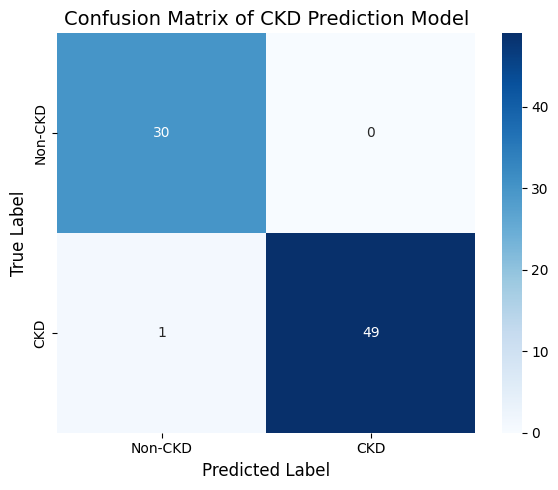

In [12]:
# 📊 Confusion Matrix Visualization (Publication Ready)

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Non-CKD", "CKD"],
            yticklabels=["Non-CKD", "CKD"])

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix of CKD Prediction Model", fontsize=14)

plt.tight_layout()
plt.show()

In [13]:
# ✅ Cell 10A – Verify features used in final model

# Combine numeric + categorical columns in correct order
feature_order = num_cols + cat_cols

print("✅ Final model feature count:", len(feature_order))
print("Features used for training:\n", feature_order)
print("="*60)

# Build processed training matrix exactly like the model saw
X_train_processed = pd.concat([
    pd.DataFrame(X_train_res[num_cols], columns=num_cols),
    pd.DataFrame(X_train_res[cat_cols], columns=cat_cols)
], axis=1)

print("X_train_processed shape:", X_train_processed.shape)
print("="*60)

# Show a few processed rows
display(X_train_processed.head(3))

# Confirm target label mapping
print("Target mapping (LabelEncoder):", dict(enumerate(target_le.classes_)))

✅ Final model feature count: 24
Features used for training:
 ['Age', 'Blood_Pressure', 'Specific_Gravity', 'Albumin', 'Sugar', 'Blood_Glucose_Random', 'Blood_Urea', 'Serum_Creatinine', 'Sodium', 'Potassium', 'Hemoglobin', 'Packed_Cell_Volume', 'White_Blood_Cell_Count', 'Red_Blood_Cell_Count', 'Red_Blood_Cells', 'Pus_Cells', 'Pus_Cell_Clumps', 'Bacteria', 'Hypertension', 'Diabetes_Mellitus', 'Coronary_Artery_Disease', 'Appetite', 'Pedal_Edema', 'Anemia']
X_train_processed shape: (400, 24)


,Age,Blood_Pressure,Specific_Gravity,Albumin,Sugar,Blood_Glucose_Random,Blood_Urea,Serum_Creatinine,Sodium,Potassium,...,Red_Blood_Cells,Pus_Cells,Pus_Cell_Clumps,Bacteria,Hypertension,Diabetes_Mellitus,Coronary_Artery_Disease,Appetite,Pedal_Edema,Anemia
0,-0.325056,0.333569,-0.641861,-0.685084,-0.359859,-0.470466,-0.856731,-0.321615,0.340297,-0.248859,...,1,0,1,1,1,1,1,0,1,1
1,0.523822,1.869666,-0.641861,2.689826,1.929900,1.785439,1.790544,1.888241,-0.324362,2.155577,...,2,2,1,1,2,2,2,0,1,2
2,-0.325056,-1.202528,-1.613412,1.002371,-0.359859,1.983593,0.749735,0.240213,-0.435139,1.193803,...,2,0,2,1,2,2,1,0,1,1


Target mapping (LabelEncoder): {0: 'ckd', 1: 'notckd'}


Showing SHAP summary for 80 samples.


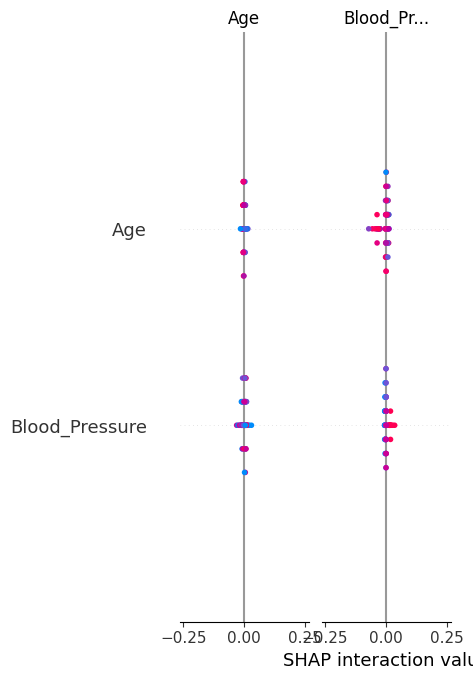

In [14]:
# Cell 11 - SHAP explainability using RandomForest for speed and interpretability
try:
    explainer = shap.TreeExplainer(rf)
    sample_size = min(100, len(X_test))
    sample = X_test.sample(sample_size, random_state=42)
    shap_values = explainer.shap_values(sample)
    print(f"Showing SHAP summary for {sample_size} samples.")
    shap.summary_plot(shap_values, sample, show=True)
except Exception as e:
    print("SHAP generation failed or slow in this environment:", e)
    # Show RF feature importances as fallback
    fi = pd.Series(rf.feature_importances_, index=X_test.columns).sort_values(ascending=False)
    print("Top RandomForest feature importances:\n", fi.head(15))

In [15]:
# ✅ Cell 12 - Fixed version for column order mismatch

def prepare_and_predict(case_dict):
    # Create dataframe from the case dictionary
    row = pd.DataFrame([case_dict])

    # Make sure all training features exist
    for c in X_train_res.columns:
        if c not in row.columns:
            row[c] = np.nan

    # Normalize categorical inputs (strip/lower)
    for c in cat_cols:
        if c in row.columns:
            row[c] = row[c].astype(str).str.strip().str.lower()

    # Map categorical to encoded numeric values
    for c in cat_cols:
        if c in row.columns:
            encoder = encoders[c]
            enc_classes = [cls.strip().lower() for cls in encoder.classes_]
            mapping = {cls: i for i, cls in enumerate(enc_classes)}
            row[c] = row[c].map(mapping).fillna(0).astype(int)

    # Impute missing numerics with mean
    for c in num_cols:
        if c in row.columns:
            row[c] = row[c].fillna(df[c].mean())

    # Reorder columns exactly as training
    row = row[X_train_res.columns]

    # Scale numeric features
    row[num_cols] = scaler.transform(row[num_cols])

    # Predict using the trained hybrid model
    pred = hybrid.predict(row)[0]
    prob = hybrid.predict_proba(row)[0][1] if hasattr(hybrid, "predict_proba") else None

    label = "CKD" if pred == 1 else "No CKD"
    return {"label": label, "probability": float(prob) if prob is not None else None}


# 🧪 Test cases
ckd_case = {
    'age':70,'bp':100,'sg':1.005,'al':4,'su':3,'rbc':'abnormal','pc':'abnormal',
    'pcc':'present','ba':'present','bgr':260,'bu':95,'sc':4.2,'sod':128,'pot':5.8,
    'hemo':9.5,'pcv':28,'wc':10200,'rc':3.3,'htn':'yes','dm':'yes','cad':'yes',
    'appet':'poor','pe':'yes','ane':'yes'
}

healthy_case = {
    'age':35,'bp':80,'sg':1.020,'al':0,'su':0,'rbc':'normal','pc':'normal',
    'pcc':'notpresent','ba':'notpresent','bgr':100,'bu':30,'sc':1.1,'sod':140,'pot':4.3,
    'hemo':14.5,'pcv':45,'wc':7200,'rc':5.0,'htn':'no','dm':'no','cad':'no',
    'appet':'good','pe':'no','ane':'no'
}

print("CKD case prediction:", prepare_and_predict(ckd_case))
print("Healthy case prediction:", prepare_and_predict(healthy_case))

CKD case prediction: {'label': 'CKD', 'probability': 0.9077320003220705}
Healthy case prediction: {'label': 'CKD', 'probability': 0.9077320003220705}


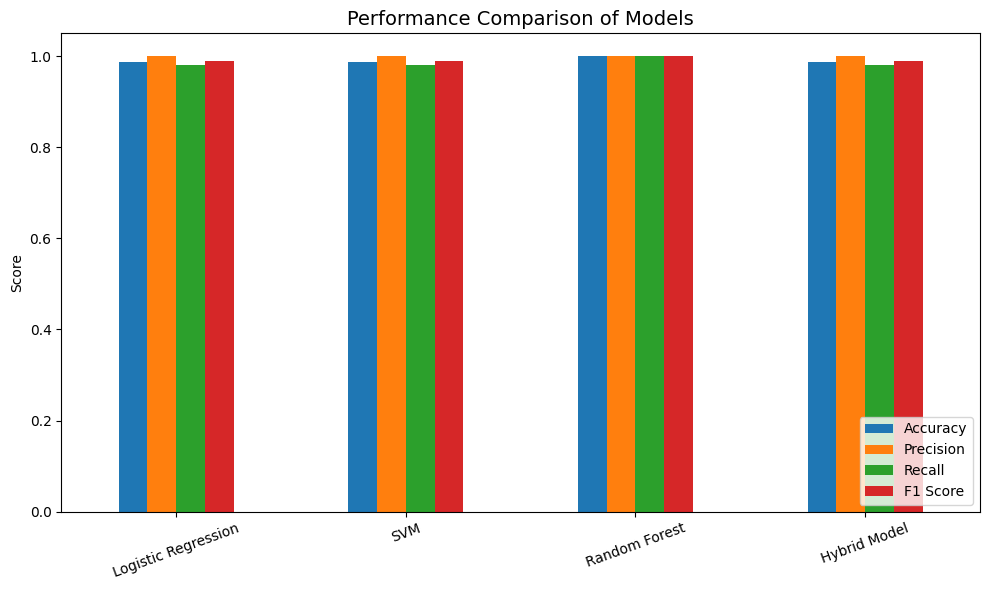

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.9875,1.0,0.98,0.989899
SVM,0.9875,1.0,0.98,0.989899
Random Forest,1.0000,1.0,1.00,1.000000
Hybrid Model,0.9875,1.0,0.98,0.989899


In [16]:
# 📊 Model Performance Comparison

models = {
    "Logistic Regression": lr,
    "SVM": svc,
    "Random Forest": rf,
    "Hybrid Model": hybrid
}

results = {}

for name, model in models.items():
    y_pred_temp = model.predict(X_test)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred_temp),
        "Precision": precision_score(y_test, y_pred_temp, zero_division=0),
        "Recall": recall_score(y_test, y_pred_temp, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred_temp, zero_division=0)
    }

# Convert to DataFrame
import pandas as pd
results_df = pd.DataFrame(results).T

# Plot
results_df.plot(kind='bar', figsize=(10,6))

plt.title("Performance Comparison of Models", fontsize=14)
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

# Show values
results_df

In [17]:
# ✅ Cell 13 – Final Improved Gradio UI (Fixed for new Gradio version)

import gradio as gr

# Build input components
feature_order = num_cols + cat_cols
gr_inputs = []

for c in feature_order:
    if c in num_cols:
        gr_inputs.append(
            gr.Number(
                label=c.replace("_", " "),
                value=float(df[c].median()),
                precision=2
            )
        )
    else:
        choices = [str(x) for x in encoders[c].classes_]
        gr_inputs.append(
            gr.Dropdown(
                choices=choices,
                label=c.replace("_", " "),
                value=choices[0]
            )
        )

# Prediction function
def gradio_predict(*args):
    row = dict(zip(feature_order, args))
    for k in cat_cols:
        if k in row:
            row[k] = str(row[k]).strip().lower()
    res = prepare_and_predict(row)
    if res['probability'] is not None:
        return f"🩺 Prediction: **{res['label']}**\n📊 Probability: **{res['probability']:.2f}**"
    else:
        return f"🩺 Prediction: **{res['label']}**"

# --- Fixed layout ---
with gr.Blocks(theme=gr.themes.Soft(primary_hue="teal", secondary_hue="blue")) as iface:
    gr.Markdown(
        """
        <div style="text-align:center; background-color:#eaf6f6; padding:15px; border-radius:12px;">
            <h1 style="color:#0f4c75;">🧬 Chronic Kidney Disease Predictor</h1>
            <p style="color:#1b262c;">Enter patient details below to predict CKD likelihood using a hybrid ML model.</p>
        </div>
        """
    )

    with gr.Row():
        with gr.Column(scale=2):
            gr.Markdown("### 🔢 Enter Patient Parameters")
            with gr.Group():
                for comp in gr_inputs:
                    comp.render()

        with gr.Column(scale=1):
            gr.Markdown("### 🧾 Prediction Result")
            output_box = gr.Textbox(label="Model Output", lines=3, interactive=False)

    predict_btn = gr.Button("🔍 Predict CKD", variant="primary")
    predict_btn.click(fn=gradio_predict, inputs=gr_inputs, outputs=output_box)

    gr.Markdown(
        """
        <div style="text-align:center; margin-top:20px; font-size:14px; color:#555;">
            Developed as part of a Research Project on CKD Prediction (UCI Dataset)
        </div>
        """
    )

iface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bbb20a1fb56b842a91.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
